# Exploración de los datos

## 1. Importar las librerías

In [172]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import numpy as np
import math

## 2. Cargar datos

Cargar los datos del csv

In [173]:
datos_pacientes = pd.read_csv('./data/Datos Lab 1.csv', )

Trabajar sobre una copia de los datos

In [174]:
datos = datos_pacientes.copy()

Qué representan los datos compartidos

In [175]:
datos.head()

,Patient ID,Date of Service,Sex,Age,Weight (kg),Height (m),BMI,Abdominal Circumference (cm),Blood Pressure (mmHg),Total Cholesterol (mg/dL),...,Physical Activity Level,Family History of CVD,Height (cm),Waist-to-Height Ratio,Systolic BP,Diastolic BP,Blood Pressure Category,Estimated LDL (mg/dL),CVD Risk Score,CVD Risk Level
0,isDx5313,"November 08, 2023",M,44.0,114.300,1.720,38.600,100.000,112/83,228.0,...,High,N,172.000,0.581,112.0,83.0,Hypertension Stage 1,121.0,19.880,HIGH
1,LHCK2961,20/03/2024,F,57.0,92.923,1.842,33.116,106.315,101/91,158.0,...,High,Y,184.172,0.577,101.0,91.0,Hypertension Stage 2,57.0,16.833,INTERMEDIARY
2,WjVn1699,2021-05-27,F,NaN,73.400,1.650,27.000,78.100,90/74,135.0,...,High,N,165.000,0.473,90.0,74.0,Normal,45.0,12.600,LOW
3,dCDO1109,"April 18, 2022",F,35.0,113.300,1.780,35.800,79.600,92/89,158.0,...,Moderate,Y,178.000,0.447,92.0,89.0,Hypertension Stage 1,94.0,14.920,HIGH
4,pnpE1080,01/11/2024,F,48.0,102.200,1.750,33.400,106.700,121/68,207.0,...,Low,Y,175.000,0.610,121.0,68.0,Elevated,128.0,18.870,HIGH


## Corregir los problemas de calidad de datos

### Completitud

Detección de datos faltantes

In [176]:
pd.DataFrame({
    "faltantes": datos.isnull().sum(),
    "porcentaje_%": (datos.isnull().sum() / len(datos) * 100).round(2)
})

,faltantes,porcentaje_%
Patient ID,0,0.00
Date of Service,0,0.00
Sex,0,0.00
Age,68,4.15
Weight (kg),73,4.45
Height (m),61,3.72
BMI,53,3.23
Abdominal Circumference (cm),61,3.72
Blood Pressure (mmHg),0,0.00
Total Cholesterol (mg/dL),68,4.15


#### Correcciones a partir de fórmulas matemáticas

##### BMI, Height y Weight

Partiendo de que BMI = Weight (kg) / (Height (m))^2

Detectar casos donde falta Height pero hay Weight y BMI

In [177]:
condicion = (
    datos["Height (m)"].isna() &
    datos["Weight (kg)"].notna() &
    datos["BMI"].notna()
)

datos[condicion].head()

,Patient ID,Date of Service,Sex,Age,Weight (kg),Height (m),BMI,Abdominal Circumference (cm),Blood Pressure (mmHg),Total Cholesterol (mg/dL),...,Physical Activity Level,Family History of CVD,Height (cm),Waist-to-Height Ratio,Systolic BP,Diastolic BP,Blood Pressure Category,Estimated LDL (mg/dL),CVD Risk Score,CVD Risk Level
81,NBUl2902,01-21-2025,F,62.0,87.544,NaN,38.527,86.487,154/60,125.0,...,Moderate,Y,178.337,0.485,154.0,60.0,Hypertension Stage 2,47.0,19.905,HIGH
152,XZCU4466,22/01/2024,F,52.0,97.800,NaN,31.600,94.800,124/92,216.0,...,High,N,176.000,0.539,124.0,92.0,Hypertension Stage 2,136.0,18.840,HIGH
155,SdtW2617,21/06/2021,M,NaN,115.400,NaN,36.800,91.900,142/64,NaN,...,High,N,177.000,0.519,142.0,64.0,Hypertension Stage 2,67.0,19.180,HIGH
162,QoLE0357,24 Jun 25,F,42.0,84.600,NaN,30.300,77.900,104/62,236.0,...,High,Y,167.000,0.466,104.0,62.0,Normal,136.0,30.840,HIGH
196,EsZI4603,"July 03, 2020",F,79.0,110.631,NaN,19.288,102.272,176/89,261.0,...,High,Y,174.123,0.587,NaN,NaN,Hypertension Stage 1,175.0,19.878,LOW


Recalcular Height en esos casos

In [178]:
datos.loc[condicion, "Height (m)"] = np.sqrt(
    datos.loc[condicion, "Weight (kg)"] /
    datos.loc[condicion, "BMI"]
)
datos[condicion].head()

,Patient ID,Date of Service,Sex,Age,Weight (kg),Height (m),BMI,Abdominal Circumference (cm),Blood Pressure (mmHg),Total Cholesterol (mg/dL),...,Physical Activity Level,Family History of CVD,Height (cm),Waist-to-Height Ratio,Systolic BP,Diastolic BP,Blood Pressure Category,Estimated LDL (mg/dL),CVD Risk Score,CVD Risk Level
81,NBUl2902,01-21-2025,F,62.0,87.544,1.507407,38.527,86.487,154/60,125.0,...,Moderate,Y,178.337,0.485,154.0,60.0,Hypertension Stage 2,47.0,19.905,HIGH
152,XZCU4466,22/01/2024,F,52.0,97.800,1.759243,31.600,94.800,124/92,216.0,...,High,N,176.000,0.539,124.0,92.0,Hypertension Stage 2,136.0,18.840,HIGH
155,SdtW2617,21/06/2021,M,NaN,115.400,1.770839,36.800,91.900,142/64,NaN,...,High,N,177.000,0.519,142.0,64.0,Hypertension Stage 2,67.0,19.180,HIGH
162,QoLE0357,24 Jun 25,F,42.0,84.600,1.670952,30.300,77.900,104/62,236.0,...,High,Y,167.000,0.466,104.0,62.0,Normal,136.0,30.840,HIGH
196,EsZI4603,"July 03, 2020",F,79.0,110.631,2.394941,19.288,102.272,176/89,261.0,...,High,Y,174.123,0.587,NaN,NaN,Hypertension Stage 1,175.0,19.878,LOW


Hacer lo mismo si falta Weight

In [179]:
condicion_weight = (
    datos["Weight (kg)"].isna() &
    datos["Height (m)"].notna() &
    datos["BMI"].notna()
)

datos.loc[condicion_weight, "Weight (kg)"] = (
    datos.loc[condicion_weight, "BMI"] *
    datos.loc[condicion_weight, "Height (m)"]**2
)

Hacer lo mismo si falta BMI

In [180]:
condicion_bmi = (
    datos["BMI"].isna() &
    datos["Weight (kg)"].notna() &
    datos["Height (m)"].notna()
)

datos.loc[condicion_bmi, "BMI"] = (
    datos.loc[condicion_bmi, "Weight (kg)"] /
    (datos.loc[condicion_bmi, "Height (m)"]**2)
)

Verificamos si hay filas con 2 o más datos faltantes entre esos 3

In [181]:
datos[["Weight (kg)", "Height (m)", "BMI"]].isna().sum()

Weight (kg)    6
Height (m)     7
BMI            3
dtype: int64

Borramos las filas que tienen 2 o más ya que son <<1%

In [182]:
datos = datos.dropna(subset=["Weight (kg)", "Height (m)", "BMI"])

##### Height (m) <-> Height (cm)

Partiendo de que 1 metro son 100 cm

Si falta en cm

In [183]:
cond_cm = datos["Height (cm)"].isna() & datos["Height (m)"].notna()

datos.loc[cond_cm, "Height (cm)"] = (
    datos.loc[cond_cm, "Height (m)"] * 100
)

Si falta en m

In [184]:
cond_m = datos["Height (m)"].isna() & datos["Height (cm)"].notna()

datos.loc[cond_m, "Height (m)"] = (
    datos.loc[cond_m, "Height (cm)"] / 100
)

##### Waist-to-Height Ratio

Partiendo de que WHR = Abdominal Circumference (cm)/Height (cm)

Si falta Waist-to-Height Ratio

In [185]:
cond_whr = (
    datos["Waist-to-Height Ratio"].isna() &
    datos["Abdominal Circumference (cm)"].notna() &
    datos["Height (cm)"].notna()
)

datos.loc[cond_whr, "Waist-to-Height Ratio"] = (
    datos.loc[cond_whr, "Abdominal Circumference (cm)"] /
    datos.loc[cond_whr, "Height (cm)"]
)

##### Abdominal Circumference (cm)

Partiendo de que Abdominal Circumference (cm) = WHR * Height (cm)

In [186]:
cond_abd = (
    datos["Waist-to-Height Ratio"].notna() &
    datos["Abdominal Circumference (cm)"].isna() &
    datos["Height (cm)"].notna()
)

datos.loc[cond_abd, "Abdominal Circumference (cm)"] = (
    datos.loc[cond_abd, "Waist-to-Height Ratio"] *
    datos.loc[cond_abd, "Height (cm)"]
)

Borramos el resto de filas que tienen 2 o más datos faltantes entre (Abdominal Circumference (cm), WHR, Height (cm)) ya que son <<1%

In [187]:
datos = datos.dropna(subset=["Waist-to-Height Ratio", "Abdominal Circumference (cm)", "Height (cm)"])

##### Systolic + Diastolic ↔ Blood Pressure (mmHg)

Dividimos la columna de Blood Pressure (mmHg) en Systolic y Diastolic

In [188]:
bp_split = datos["Blood Pressure (mmHg)"].str.split("/", expand=True)

Completamos Systolic

In [189]:
cond_sys = (
    datos["Systolic BP"].isna() &
    datos["Blood Pressure (mmHg)"].notna()
)

datos.loc[cond_sys, "Systolic BP"] = bp_split.loc[cond_sys, 0].astype(float)

Completamos Diastolic

In [190]:
cond_dia = (
    datos["Diastolic BP"].isna() &
    datos["Blood Pressure (mmHg)"].notna()
)

datos.loc[cond_dia, "Diastolic BP"] = bp_split.loc[cond_dia, 1].astype(float)

#### Imputación estadística

Tras aplicar imputaciones determinísticas basadas en relaciones fisiológicas y conversiones de unidades, no se identificaron variables adicionales susceptibles de reconstrucción matemática. Los valores faltantes restantes corresponden a mediciones clínicas independientes, por lo que se empleó imputación estadística mediante la mediana.

In [191]:
cols_mediana = [
    "Age",
    "Total Cholesterol (mg/dL)",
    "HDL (mg/dL)",
    "Fasting Blood Sugar (mg/dL)",
    "Estimated LDL (mg/dL)",
    "CVD Risk Score"
]

for col in cols_mediana:
    datos[col] = datos[col].fillna(datos[col].median())

#### Conclusiones

El análisis de completitud evidenció un bajo porcentaje de valores faltantes (<6%), los cuales fueron resueltos mediante imputaciones determinísticas cuando existían relaciones matemáticas entre variables y, posteriormente, mediante imputación por mediana en variables clínicas independientes, logrando un conjunto de datos completo sin pérdida significativa de información.

### Unicidad

#### Eliminar filas duplicadas

Primero verificamos si hay filas idénticas

In [192]:
datos.duplicated().sum()

np.int64(150)

Borramos los duplicados

In [193]:
datos = datos.drop_duplicates()

#### Eliminar filas duplicadas por clave

Primero debemos estandarizar las fechas

In [194]:
datos["Date of Service"] = pd.to_datetime(
    datos["Date of Service"],
    format="mixed",   # permite múltiples formatos
    dayfirst=True,    # interpreta correctamente DD/MM/YYYY
    errors="coerce"   # valores inválidos → NaT
)

In [195]:
duplicados = datos.duplicated(
    subset=["Patient ID", "Date of Service"],
    keep=False
)

datos[duplicados].sort_values(["Patient ID", "Date of Service"])

datos = datos.drop_duplicates(
    subset=["Patient ID", "Date of Service"]
)

Verificamos que ya no hayan duplicados

In [196]:
datos.duplicated(
    subset=["Patient ID", "Date of Service"]
).sum()

np.int64(0)

### Validez

#### Detección de atípicos

##### Boxplots de todas las variables numéricas

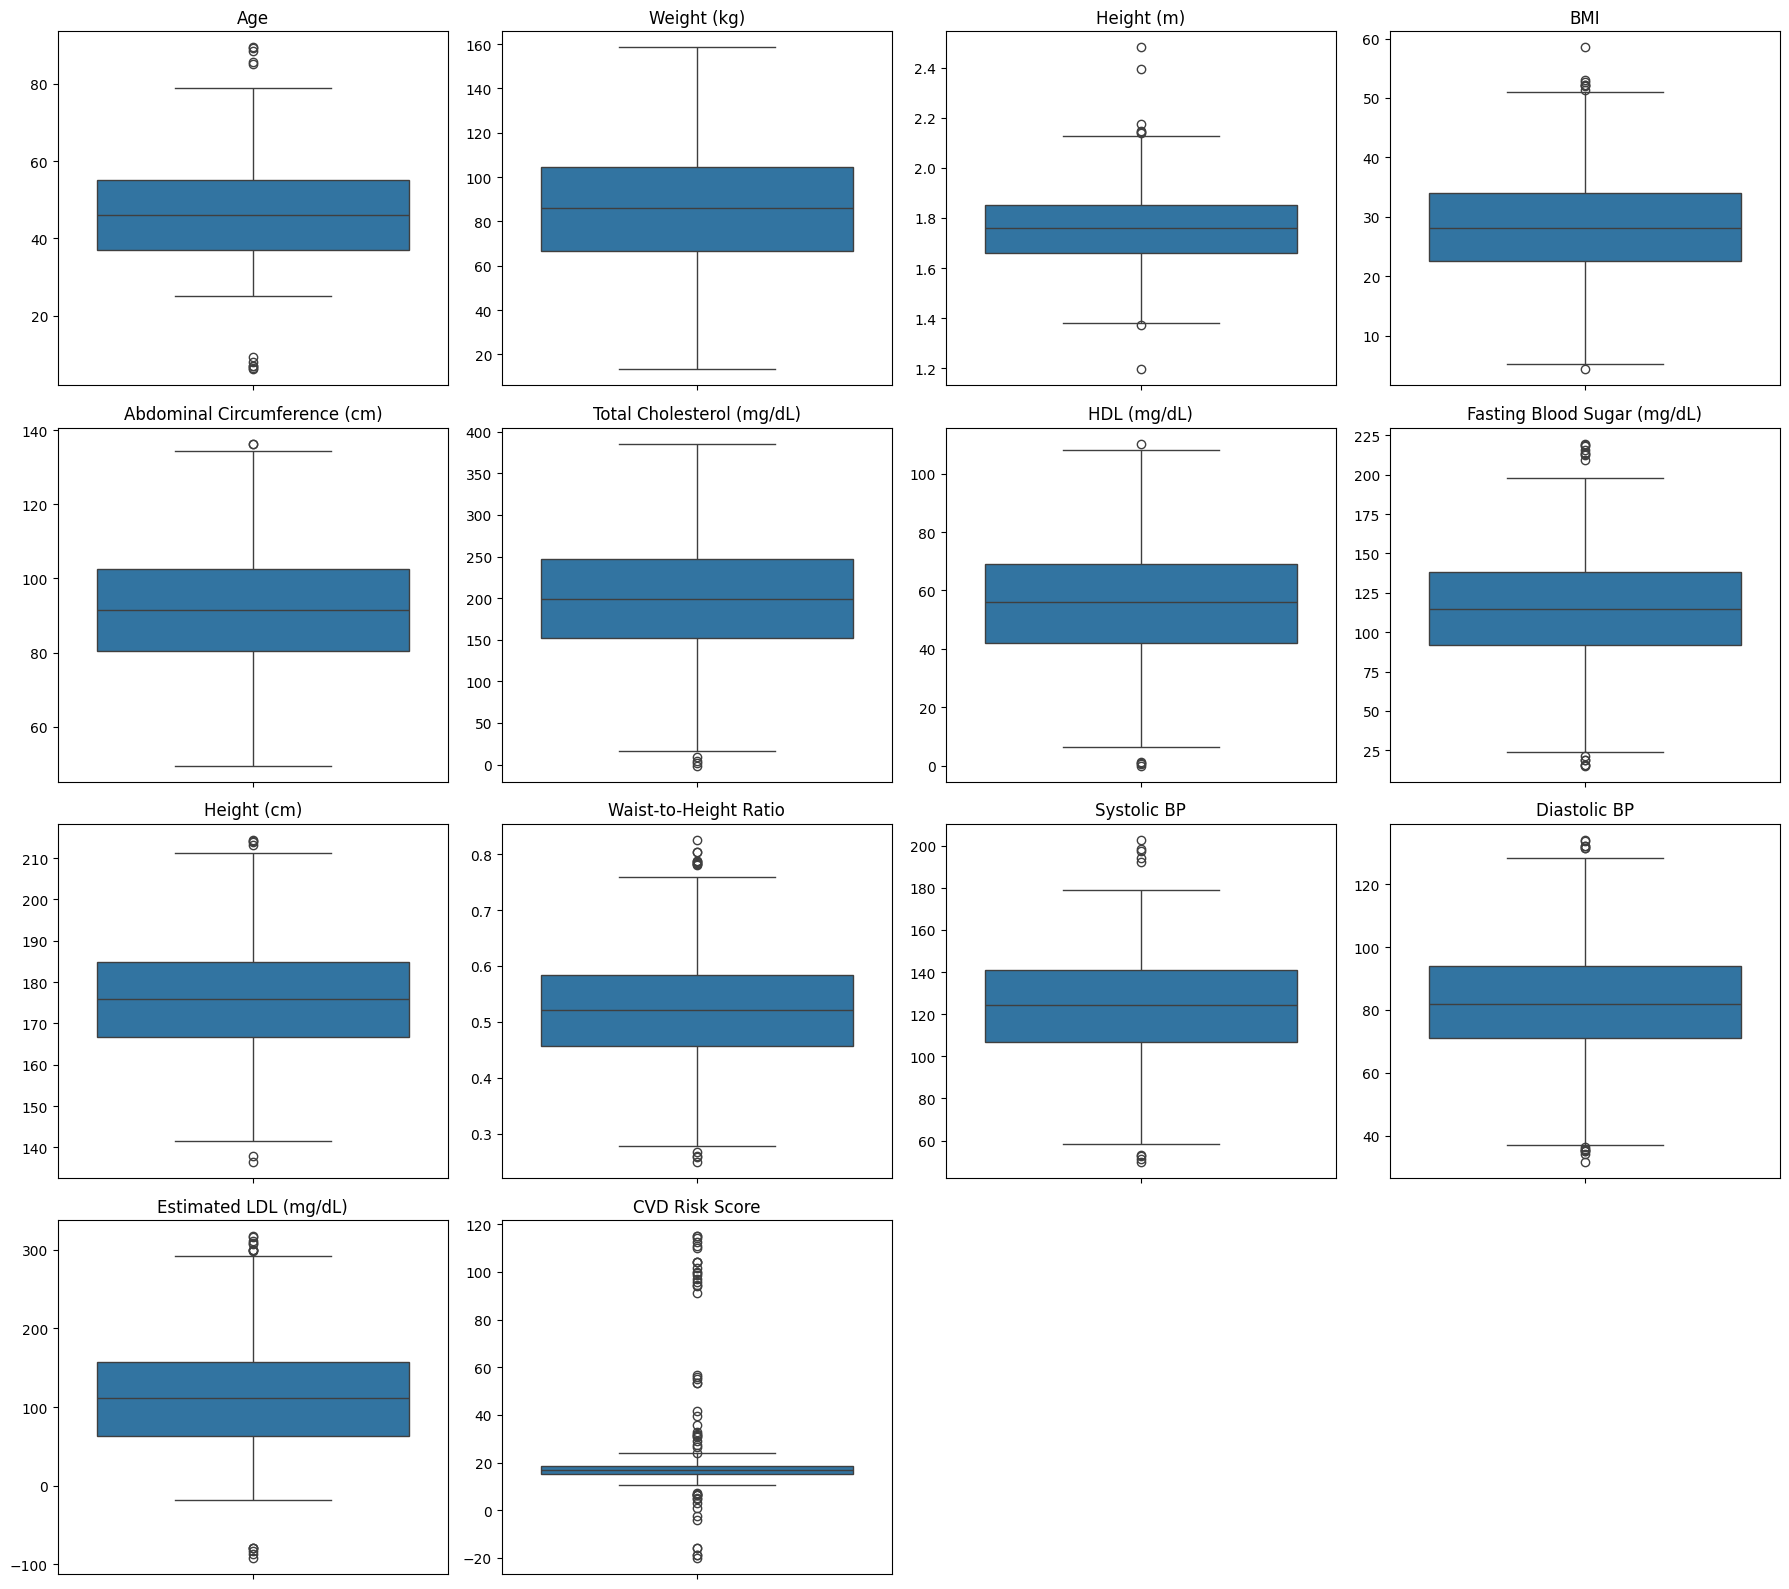

In [197]:
# Seleccionar columnas numéricas
num_cols = datos.select_dtypes(include="number").columns

# Definir tamaño del grid
n_cols = 4  # número de gráficos por fila
n_rows = math.ceil(len(num_cols) / n_cols)

# Crear figura
plt.figure(figsize=(18, 4 * n_rows))

# Crear un boxplot por variable
for i, col in enumerate(num_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(y=datos[col])
    plt.title(col)
    plt.ylabel("")
    
plt.tight_layout()
plt.show()

#### Detección exhaustiva + corrección

##### Asegurar tipos numéricos

In [198]:
# Columnas numéricas esperadas
num_cols = [
    "Age","Weight (kg)","Height (m)","BMI","Abdominal Circumference (cm)",
    "Total Cholesterol (mg/dL)","HDL (mg/dL)","Fasting Blood Sugar (mg/dL)",
    "Height (cm)","Waist-to-Height Ratio","Systolic BP","Diastolic BP",
    "Estimated LDL (mg/dL)","CVD Risk Score"
]

for c in num_cols:
    if c in datos.columns:
        datos[c] = pd.to_numeric(datos[c], errors="coerce")

##### Normalizar strings

In [199]:
str_cols = [
    "Patient ID","Sex","Smoking Status","Diabetes Status","Physical Activity Level",
    "Family History of CVD","Blood Pressure (mmHg)","Blood Pressure Category",
    "CVD Risk Level"
]
for c in str_cols:
    if c in datos.columns:
        datos[c] = datos[c].astype("string").str.strip()

##### Reglas de rango y marcar como inválido

In [200]:
# Reglas de rango (min, max)
ranges = {
    "Age": (0, 120),
    "Weight (kg)": (0, 300),
    "Height (m)": (1.20, 2.30),
    "Height (cm)": (120, 230),
    "BMI": (10, 80),
    "Abdominal Circumference (cm)": (40, 200),
    "Waist-to-Height Ratio": (0.20, 0.90),
    "Systolic BP": (70, 250),
    "Diastolic BP": (40, 150),
    "Total Cholesterol (mg/dL)": (70, 400),
    "HDL (mg/dL)": (10, 150),
    "Fasting Blood Sugar (mg/dL)": (40, 400),
    "Estimated LDL (mg/dL)": (0, 300),
    "CVD Risk Score": (0, np.inf)  # al menos no negativo
}

invalid_counts = {}

for col, (lo, hi) in ranges.items():
    if col not in datos.columns:
        continue
    m = datos[col].notna() & ((datos[col] < lo) | (datos[col] > hi))
    invalid_counts[col] = int(m.sum())
    # Marca inválidos como NaN (para luego imputar)
    datos.loc[m, col] = np.nan

invalid_counts

{'Age': 0,
 'Weight (kg)': 0,
 'Height (m)': 3,
 'Height (cm)': 0,
 'BMI': 4,
 'Abdominal Circumference (cm)': 0,
 'Waist-to-Height Ratio': 0,
 'Systolic BP': 5,
 'Diastolic BP': 9,
 'Total Cholesterol (mg/dL)': 7,
 'HDL (mg/dL)': 7,
 'Fasting Blood Sugar (mg/dL)': 7,
 'Estimated LDL (mg/dL)': 23,
 'CVD Risk Score': 7}

##### Después de marcar como inválidos volvemos a completitud

In [201]:
cols_mediana = [
    "Age",
    "Total Cholesterol (mg/dL)",
    "HDL (mg/dL)",
    "Fasting Blood Sugar (mg/dL)",
    "Estimated LDL (mg/dL)",
    "CVD Risk Score"
]

for col in cols_mediana:
    if col in datos.columns:
        datos[col] = datos[col].fillna(datos[col].median())
        
cat_cols_moda = ["Sex","Smoking Status","Diabetes Status","Family History of CVD","Physical Activity Level","CVD Risk Level"]

for col in cat_cols_moda:
    if col in datos.columns and datos[col].isna().any():
        datos[col] = datos[col].fillna(datos[col].mode(dropna=True).iloc[0])

In [202]:
# ===============================
# 1. Completar Height (m) desde Height (cm)
# ===============================
cond_h = datos["Height (m)"].isna() & datos["Height (cm)"].notna()

datos.loc[cond_h, "Height (m)"] = (
    datos.loc[cond_h, "Height (cm)"] / 100
)

# ===============================
# 2. Completar BMI usando fórmula
# ===============================
cond_bmi = (
    datos["BMI"].isna() &
    datos["Weight (kg)"].notna() &
    datos["Height (m)"].notna()
)

datos.loc[cond_bmi, "BMI"] = (
    datos.loc[cond_bmi, "Weight (kg)"] /
    (datos.loc[cond_bmi, "Height (m)"]**2)
)

# ===============================
# 3. Recuperar presión arterial desde string
# ===============================
bp = datos["Blood Pressure (mmHg)"].str.split("/", expand=True)

# Systolic
cond_sys = datos["Systolic BP"].isna() & bp[0].notna()
datos.loc[cond_sys, "Systolic BP"] = bp.loc[cond_sys, 0].astype(float)

# Diastolic
cond_dia = datos["Diastolic BP"].isna() & bp[1].notna()
datos.loc[cond_dia, "Diastolic BP"] = bp.loc[cond_dia, 1].astype(float)

# ===============================
# 4. Imputación final con mediana (solo si aún queda algo)
# ===============================
cols_final = ["Height (m)", "BMI", "Systolic BP", "Diastolic BP"]

for col in cols_final:
    datos[col] = datos[col].fillna(datos[col].median())

# ===============================
# 5. Verificación final
# ===============================
print("Faltantes restantes:")
print(datos[cols_final].isna().sum())

Faltantes restantes:
Height (m)      0
BMI             0
Systolic BP     0
Diastolic BP    0
dtype: int64


### Consistencia

#### Heatmap de correlación

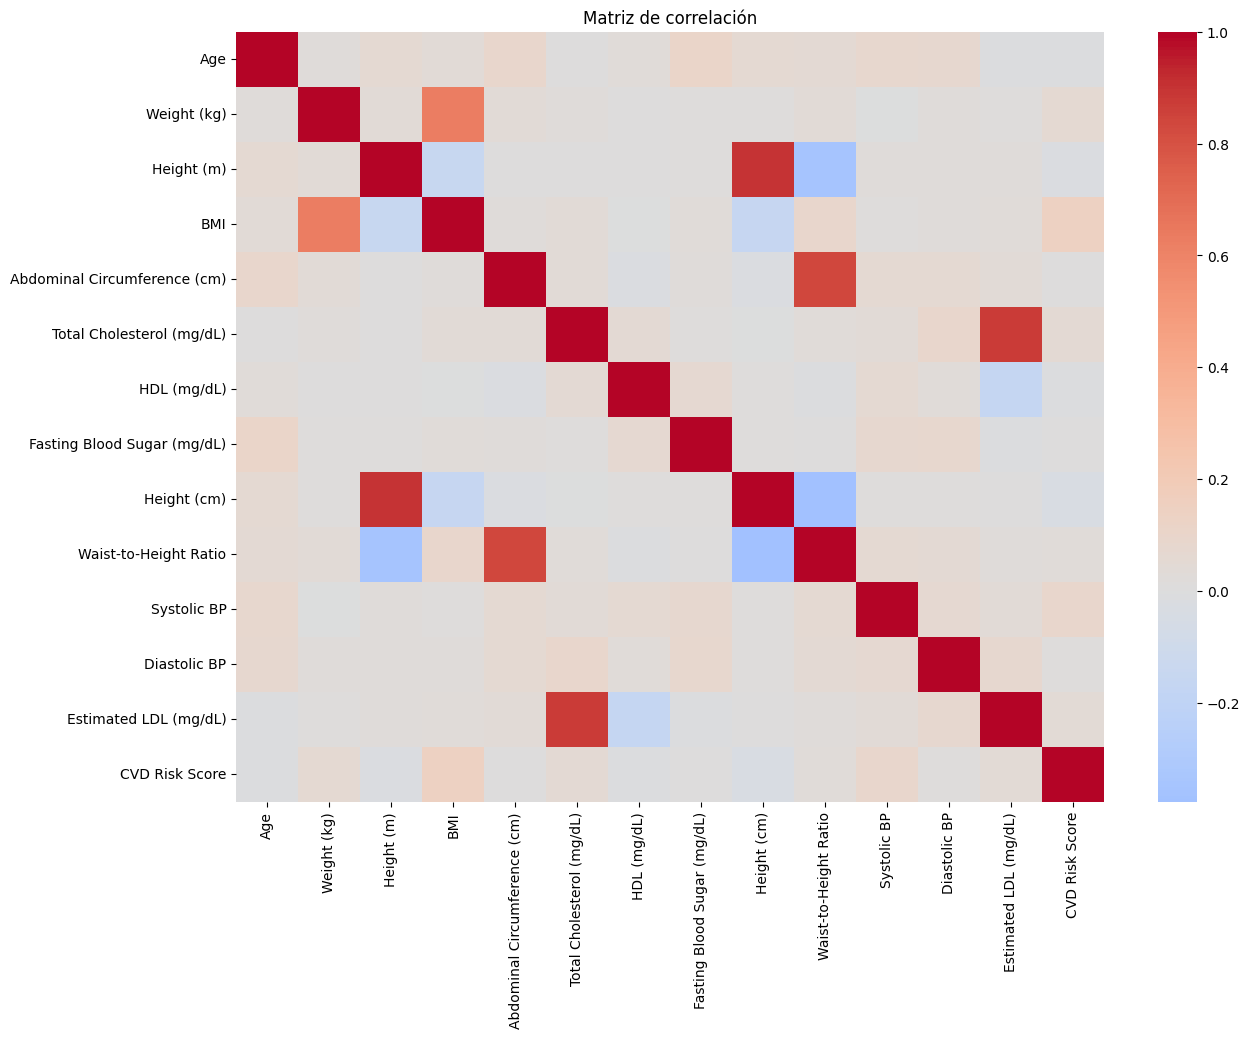

In [203]:
plt.figure(figsize=(14,10))
sns.heatmap(datos.corr(numeric_only=True),
            cmap="coolwarm",
            center=0,
            annot=False)

plt.title("Matriz de correlación")
plt.show()

#### Revisamos consistencia entre Height (m) y (cm)

In [204]:
((datos["Height (m)"]*100 - datos["Height (cm)"]).abs() > 1).sum()

np.int64(34)

Corregimos

In [205]:
datos["Height (cm)"] = datos["Height (m)"] * 100

#### Revisamos consistencia entre BMI, Weight (kg) y Height (m)

In [206]:
bmi_check = datos["Weight (kg)"]/(datos["Height (m)"]**2)

(abs(datos["BMI"] - bmi_check) > 0.1).sum()

np.int64(445)

Recalculamos el BMI

In [207]:
datos["BMI"] = datos["Weight (kg)"] / (datos["Height (m)"]**2)

Eliminamos los registros con BMI fuera del rango válido

In [208]:
# eliminar registros con BMI fuera de rango válido
datos = datos[(datos["BMI"] >= 10) & (datos["BMI"] <= 80)]

print("Nuevo tamaño del dataset:", datos.shape)

Nuevo tamaño del dataset: (1363, 24)


#### Revisamos consistencia entre Systolic BP y Diastolic BP

In [209]:
# 1. Detectar inconsistencias médicas
mask_bp = datos["Systolic BP"] < datos["Diastolic BP"]
print("Inconsistencias iniciales:", mask_bp.sum())

# 2. Extraer valores desde la fuente original
bp = datos["Blood Pressure (mmHg)"].astype("string").str.split("/", expand=True)

bp_sys = pd.to_numeric(bp[0], errors="coerce")
bp_dia = pd.to_numeric(bp[1], errors="coerce")

# 3. Reconstruir SOLO registros inconsistentes
datos.loc[mask_bp, "Systolic BP"] = bp_sys.loc[mask_bp]
datos.loc[mask_bp, "Diastolic BP"] = bp_dia.loc[mask_bp]

# 4. Revisar nuevamente
mask_bp = datos["Systolic BP"] < datos["Diastolic BP"]

# 5. Si aún quedan inconsistencias → invalidar e imputar
datos.loc[mask_bp, ["Systolic BP", "Diastolic BP"]] = np.nan

datos["Systolic BP"] = datos["Systolic BP"].fillna(datos["Systolic BP"].median())
datos["Diastolic BP"] = datos["Diastolic BP"].fillna(datos["Diastolic BP"].median())

# 6. Validación final
print("Inconsistencias finales:",
      (datos["Systolic BP"] < datos["Diastolic BP"]).sum())

Inconsistencias iniciales: 57
Inconsistencias finales: 0


#### Revalidación

In [210]:
print("Height inconsistentes:",
      ((datos["Height (m)"]*100 - datos["Height (cm)"]).abs() > 1).sum())

print("BMI inconsistentes:",
      (abs(datos["BMI"] -
           datos["Weight (kg)"]/(datos["Height (m)"]**2)) > 0.1).sum())

print("Presión arterial inconsistente:",
      (datos["Systolic BP"] < datos["Diastolic BP"]).sum())

Height inconsistentes: 0
BMI inconsistentes: 0
Presión arterial inconsistente: 0


### Verificación final

In [211]:
print("========== AUDITORÍA FINAL DE CALIDAD ==========\n")

# =================================================
# 1. COMPLETITUD
# =================================================
faltantes_totales = datos.isna().sum().sum()

print("COMPLETITUD")
print("Faltantes totales:", faltantes_totales)
print("Estado:", "✅ OK" if faltantes_totales == 0 else "❌ Hay faltantes")
print()

# =================================================
# 2. UNICIDAD
# =================================================
dup_exactos = datos.duplicated().sum()

dup_logicos = datos.duplicated(
    subset=["Patient ID", "Date of Service"]
).sum()

print("UNICIDAD")
print("Duplicados exactos:", dup_exactos)
print("Duplicados (Patient ID + Date):", dup_logicos)
print("Estado:", "✅ OK" if dup_exactos == 0 and dup_logicos == 0 else "❌ Hay duplicados")
print()

# =================================================
# 3. VALIDEZ (NUEVOS RANGOS)
# =================================================
ranges = {
    "Age": (0, 120),
    "Weight (kg)": (0, 300),
    "Height (m)": (1.20, 2.30),
    "Height (cm)": (120, 230),
    "BMI": (10, 80),
    "Abdominal Circumference (cm)": (40, 200),
    "Waist-to-Height Ratio": (0.20, 0.90),
    "Systolic BP": (70, 250),
    "Diastolic BP": (40, 150),
    "Total Cholesterol (mg/dL)": (70, 400),
    "HDL (mg/dL)": (10, 150),
    "Fasting Blood Sugar (mg/dL)": (40, 400),
    "Estimated LDL (mg/dL)": (0, 300),
    "CVD Risk Score": (0, np.inf)
}

invalid_validez = {}

for col, (lo, hi) in ranges.items():
    if col in datos.columns:
        invalid_validez[col] = int(
            ((datos[col] < lo) | (datos[col] > hi)).sum()
        )

total_invalid = sum(invalid_validez.values())

print("VALIDEZ")
print("Valores fuera de rango:", total_invalid)
print("Detalle:", invalid_validez)
print("Estado:", "✅ OK" if total_invalid == 0 else "❌ Hay valores inválidos")
print()

# =================================================
# 4. CONSISTENCIA
# =================================================
height_incons = ((datos["Height (m)"]*100 - datos["Height (cm)"]).abs() > 1).sum()

bmi_calc = datos["Weight (kg)"]/(datos["Height (m)"]**2)
bmi_incons = (abs(datos["BMI"] - bmi_calc) > 0.1).sum()

bp_incons = (datos["Systolic BP"] < datos["Diastolic BP"]).sum()

print("CONSISTENCIA")
print("Height inconsistentes:", int(height_incons))
print("BMI inconsistentes:", int(bmi_incons))
print("BP inconsistentes:", int(bp_incons))

consistencia_ok = (height_incons == 0 and bmi_incons == 0 and bp_incons == 0)

print("Estado:", "✅ OK" if consistencia_ok else "❌ Hay inconsistencias")
print()

# =================================================
# RESULTADO FINAL
# =================================================
if (
    faltantes_totales == 0
    and dup_exactos == 0
    and dup_logicos == 0
    and total_invalid == 0
    and consistencia_ok
):
    print("🎉 DATASET COMPLETAMENTE LIMPIO Y VALIDADO")
else:
    print("⚠️ Aún existen problemas de calidad de datos")

========== AUDITORÍA FINAL DE CALIDAD ==========

COMPLETITUD
Faltantes totales: 0
Estado: ✅ OK

UNICIDAD
Duplicados exactos: 0
Duplicados (Patient ID + Date): 0
Estado: ✅ OK

VALIDEZ
Valores fuera de rango: 0
Detalle: {'Age': 0, 'Weight (kg)': 0, 'Height (m)': 0, 'Height (cm)': 0, 'BMI': 0, 'Abdominal Circumference (cm)': 0, 'Waist-to-Height Ratio': 0, 'Systolic BP': 0, 'Diastolic BP': 0, 'Total Cholesterol (mg/dL)': 0, 'HDL (mg/dL)': 0, 'Fasting Blood Sugar (mg/dL)': 0, 'Estimated LDL (mg/dL)': 0, 'CVD Risk Score': 0}
Estado: ✅ OK

CONSISTENCIA
Height inconsistentes: 0
BMI inconsistentes: 0
BP inconsistentes: 0
Estado: ✅ OK

🎉 DATASET COMPLETAMENTE LIMPIO Y VALIDADO
